# LIDC-IDRI Data Exploration\n\nThis notebook explores the LIDC-IDRI dataset structure, visualizes CT scans, and analyzes annotations.

In [1]:
import shutil
from pathlib import Path

ckpt_dir = Path("./checkpoints")

if ckpt_dir.exists():
    shutil.rmtree(ckpt_dir)
    print("Old checkpoints deleted.")

ckpt_dir.mkdir(exist_ok=True)


Old checkpoints deleted.


In [2]:
import sys

!{sys.executable} -m pip install --user -r ../requirements.txt

In [3]:
import os

root = '../data/raw/LIDC-IDRI/LIDC_DATA'

for folder in os.listdir(root)[:5]:
    folder_path = os.path.join(root, folder)
    print(folder, "contains:", len(os.listdir(folder_path)), "files")


1.2.276.0.7230010.3.1.3.0.28517.1553311970.693122 contains: 2 files
1.2.276.0.7230010.3.1.3.0.3627.1553288018.313019 contains: 2 files
1.3.6.1.4.1.14519.5.2.1.6279.6001.168037818448885856452592057286 contains: 637 files
1.2.276.0.7230010.3.1.3.0.2454.1553286994.621179 contains: 2 files
1.3.6.1.4.1.14519.5.2.1.6279.6001.428038562098395445838061018440 contains: 540 files


In [4]:
import sys
sys.path.append('../src')

from data_exploration.exploration import LIDCExplorer, visualize_preprocessing_comparison

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


%matplotlib inline


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Dataset Structure Overview\n\n### LIDC-IDRI Organization:\n- **DICOM Format**: Each patient has CT scans in DICOM format\n- **Multiple Annotations**: Up to 4 radiologists annotated each scan\n- **XML Metadata**: Nodule characteristics stored in XML\n- **Malignancy Scale**: 1-5 (1=benign, 5=highly malignant)\n- **Patient-Level Folders**: LIDC-IDRI-XXXX structure

In [5]:
# Initialize explorer
DATA_ROOT = '../data/raw/LIDC-IDRI/LIDC_DATA'
explorer = LIDCExplorer(DATA_ROOT)

# List patients
patients = explorer.list_patients()

print(f'Total patients found: {len(patients)}')
print(f'First 5 patients: {patients[:5]}')


Total patients found: 1018
First 5 patients: ['1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100332161840553388986847034053', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793540579077826395208', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100530488926682752765845212286', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100620385482151095585000946543']


## 2. Load and Visualize CT Scan

In [6]:
# Load a sample patient
if len(patients) > 0:
    patient_id = patients[0]
    print(f'Loading patient: {patient_id}')
    
    # Load DICOM slices
    slices = explorer.load_dicom_scan(patient_id)
    print(f'Number of slices: {len(slices)}')
    
    # Convert to HU
    volume_hu = explorer.get_pixels_hu(slices)
    print(f'Volume shape: {volume_hu.shape}')
    print(f'HU range: [{volume_hu.min()}, {volume_hu.max()}]')
    
    # Get spacing
    spacing = explorer.get_spacing(slices)
    print(f'Voxel spacing (mm): {spacing}')


Loading patient: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
Found 194 total DICOM files for 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
Selected CT series: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
Number of CT slices: 194
Number of slices: 194
Volume shape: (194, 512, 512)
HU range: [-1024, 3071]
Voxel spacing (mm): (2.0, 0.64453125, 0.64453125)


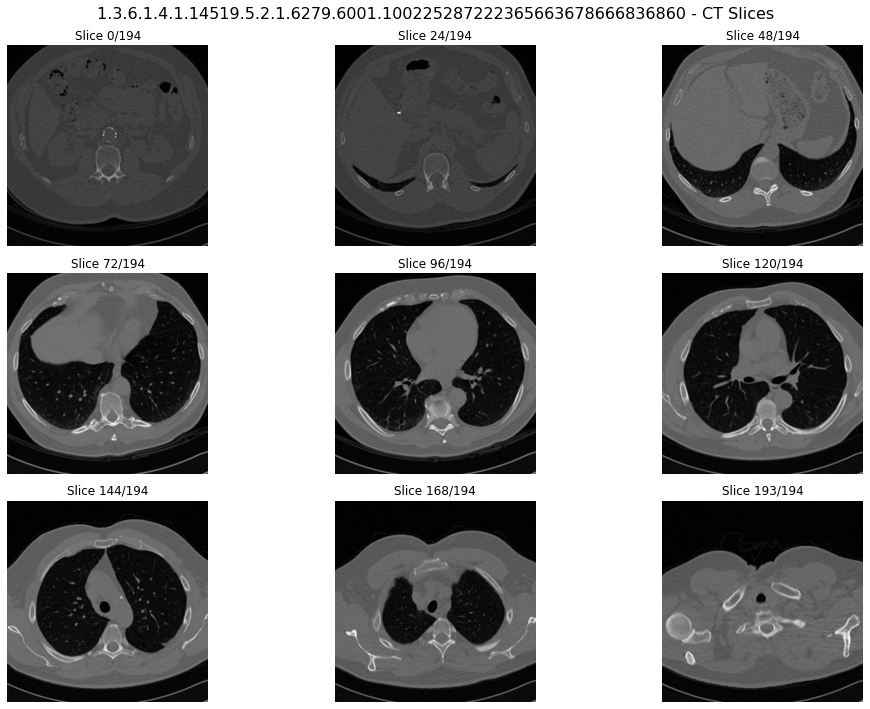

In [7]:
# Visualize multiple slices
if len(patients) > 0:
    explorer.plot_slices(
        volume_hu,
        num_slices=9,
        title=f'{patient_id} - CT Slices'
    )


## 3. HU Distribution Analysis

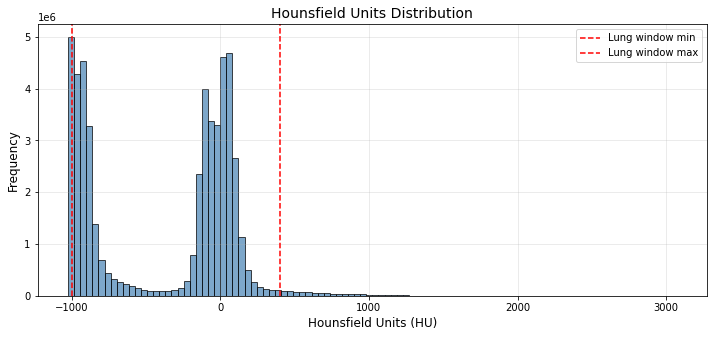

In [8]:
# Plot HU histogram
if len(patients) > 0:
    explorer.plot_histogram(
        volume_hu,
        bins=100,
        title='Hounsfield Units Distribution'
    )


## 4. Annotation Analysis\n\nParse XML annotations to extract nodule characteristics.

In [9]:
# Parse annotations
if len(patients) > 0:
    nodules = explorer.parse_xml_annotations(patient_id)
    print(f'Number of nodule annotations: {len(nodules)}')
    
    if len(nodules) > 0:
        # Create summary DataFrame
        df = explorer.create_summary_df(nodules)
        display(df.head())


Number of nodule annotations: 0


## 5. Malignancy Distribution\n\nAnalyze distribution of malignancy scores across all annotations.

In [10]:
# This would require processing all patients - example code
# In practice, you would iterate through all patients

print('To analyze all patients, run the preprocessing pipeline first.')
print('This will generate metadata CSV with complete annotations.')


To analyze all patients, run the preprocessing pipeline first.
This will generate metadata CSV with complete annotations.


## Summary\n\nKey findings from data exploration:\n- LIDC-IDRI contains CT scans in DICOM format\n- Variable number of slices per patient (typically 100-500)\n- HU values span lung window [-1000, 400]\n- Multiple radiologist annotations per nodule\n- Need preprocessing: resampling, normalization, patch extraction